In [108]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             roc_auc_score)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [109]:
# Set random seed for reproducibility
np.random.seed(42)

n = 1000

# Seller IDs
seller_ids = [f"S{str(i).zfill(4)}" for i in range(1, n+1)]

# Application dates
application_dates = pd.date_range(end="2024-12-31", periods=n, freq="D").to_numpy()
np.random.shuffle(application_dates)

# Country
countries = np.random.choice(["Saudi Arabia", "UAE"], size=n, p=[0.6, 0.4])

# Funnel steps — churners take longer by design
churned_mask = np.random.rand(n) < 0.25

days_company   = np.where(churned_mask,
                           np.random.randint(15, 60, n),
                           np.random.randint(1, 55, n))
days_logistics = np.where(churned_mask,
                           np.random.randint(10, 45, n),
                           np.random.randint(1, 42, n))
days_license   = np.where(churned_mask,
                           np.random.randint(20, 90, n),
                           np.random.randint(1, 80, n))
days_agreement = np.where(churned_mask,
                           np.random.randint(5, 30, n),
                           np.random.randint(1, 28, n))

followup_count      = np.where(churned_mask,
                                np.random.randint(0, 10, n),
                                np.random.randint(2, 15, n))
days_since_followup = np.where(churned_mask,
                                np.random.randint(15, 120, n),
                                np.random.randint(0, 90, n))

reached_activation  = np.where(churned_mask,
                                np.random.choice([0, 1], n, p=[0.75, 0.25]),
                                np.random.choice([0, 1], n, p=[0.35, 0.65])).astype(int)
churned             = churned_mask.astype(int)


# Add label noise — flip 15% of churn labels randomly
noise_idx = np.random.choice(n, size=int(n * 0.15), replace=False)
churned[noise_idx] = 1 - churned[noise_idx]


# Add noise to activation
activation_noise = np.random.choice(n, size=int(n * 0.10), replace=False)
reached_activation[activation_noise] = 1 - reached_activation[activation_noise]
# Build DataFrame
df = pd.DataFrame({
    "seller_id":                          seller_ids,
    "application_date":                   application_dates,
    "country":                            countries,
    "days_to_complete_company_details":   days_company,
    "days_to_complete_logistics":         days_logistics,
    "days_to_upload_license":             days_license,
    "days_to_sign_agreement":             days_agreement,
    "total_onboarding_days":              total_days,
    "followup_count":                     followup_count,
    "days_since_last_followup":           days_since_followup,
    "reached_activation":                 reached_activation,
    "churned":                            churned
})

print(f"✅ Dataset created: {df.shape[0]} sellers, {df.shape[1]} columns")
print(f"📊 Churn rate: {df['churned'].mean():.1%}")

✅ Dataset created: 1000 sellers, 12 columns
📊 Churn rate: 33.1%


In [110]:
# First look at the dataset
print("🔍 First 5 rows:")
display(df.head())

print("\n📋 Dataset Info:")
print(df.info())

print("\n📊 Summary Statistics:")
display(df.describe())

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🌍 Sellers by Country:")
print(df["country"].value_counts())

print("\n🎯 Churn Distribution:")
print(df["churned"].value_counts())
print(f"Churn Rate: {df['churned'].mean():.1%}")

🔍 First 5 rows:


,seller_id,application_date,country,days_to_complete_company_details,days_to_complete_logistics,days_to_upload_license,days_to_sign_agreement,total_onboarding_days,followup_count,days_since_last_followup,reached_activation,churned
0,S0001,2023-09-10,UAE,44,33,72,21,184,9,53,0,1
1,S0002,2024-04-13,Saudi Arabia,19,28,65,17,62,8,60,1,0
2,S0003,2024-04-16,UAE,48,41,87,22,171,0,84,0,1
3,S0004,2024-01-27,Saudi Arabia,24,16,1,18,70,6,73,0,0
4,S0005,2023-05-23,UAE,11,20,2,4,75,9,9,1,0



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   seller_id                         1000 non-null   object        
 1   application_date                  1000 non-null   datetime64[ns]
 2   country                           1000 non-null   object        
 3   days_to_complete_company_details  1000 non-null   int64         
 4   days_to_complete_logistics        1000 non-null   int64         
 5   days_to_upload_license            1000 non-null   int64         
 6   days_to_sign_agreement            1000 non-null   int64         
 7   total_onboarding_days             1000 non-null   int64         
 8   followup_count                    1000 non-null   int64         
 9   days_since_last_followup          1000 non-null   int64         
 10  reached_activation              

,application_date,days_to_complete_company_details,days_to_complete_logistics,days_to_upload_license,days_to_sign_agreement,total_onboarding_days,followup_count,days_since_last_followup,reached_activation,churned
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2023-08-19 12:00:00,29.638000,22.380000,44.335000,15.098000,99.644000,7.08900,49.597000,0.542000,0.331000
min,2022-04-07 00:00:00,1.000000,1.000000,1.000000,1.000000,14.000000,0.00000,0.000000,0.000000,0.000000
25%,2022-12-12 18:00:00,17.000000,12.000000,25.750000,9.000000,69.000000,4.00000,25.000000,0.000000,0.000000
50%,2023-08-19 12:00:00,30.000000,23.000000,46.000000,15.000000,92.000000,7.00000,49.000000,1.000000,0.000000
75%,2024-04-25 06:00:00,43.000000,33.000000,63.000000,22.000000,127.000000,10.00000,72.000000,1.000000,1.000000
max,2024-12-31 00:00:00,59.000000,44.000000,89.000000,29.000000,208.000000,14.00000,118.000000,1.000000,1.000000
std,NaN,15.417739,11.846178,22.820244,7.727361,40.940779,3.86316,28.847682,0.498482,0.470809



❓ Missing Values:
seller_id                           0
application_date                    0
country                             0
days_to_complete_company_details    0
days_to_complete_logistics          0
days_to_upload_license              0
days_to_sign_agreement              0
total_onboarding_days               0
followup_count                      0
days_since_last_followup            0
reached_activation                  0
churned                             0
dtype: int64

🌍 Sellers by Country:
country
Saudi Arabia    584
UAE             416
Name: count, dtype: int64

🎯 Churn Distribution:
churned
0    669
1    331
Name: count, dtype: int64
Churn Rate: 33.1%


In [111]:
# Feature Engineering
today = pd.Timestamp("2024-12-31")

# 1. How long ago did the seller apply?
df["days_since_application"] = (today - df["application_date"]).dt.days

# 2. How many funnel steps did the seller complete?
df["steps_completed"] = (
    (df["days_to_complete_company_details"] > 0).astype(int) +
    (df["days_to_complete_logistics"] > 0).astype(int) +
    (df["days_to_upload_license"] > 0).astype(int) +
    (df["days_to_sign_agreement"] > 0).astype(int)
)

# 3. Average days per funnel step
df["avg_days_per_step"] = df["total_onboarding_days"] / df["steps_completed"]

# 4. How effective are follow-ups?
df["followup_effectiveness"] = df["followup_count"] / (df["total_onboarding_days"] + 1)

# 5. Is the seller taking too long? (1 = yes, 0 = no)
df["is_slow_onboarding"] = (df["total_onboarding_days"] > 90).astype(int)

# 6. Is the seller being neglected by the onboarding team?
df["is_neglected"] = (df["days_since_last_followup"] > 30).astype(int)

print("✅ Feature engineering complete")
print(f"📊 New shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n🆕 New columns created:")
new_cols = ["days_since_application", "steps_completed",
            "avg_days_per_step", "followup_effectiveness",
            "is_slow_onboarding", "is_neglected"]
display(df[new_cols].head())

✅ Feature engineering complete
📊 New shape: 1000 rows, 18 columns

🆕 New columns created:


,days_since_application,steps_completed,avg_days_per_step,followup_effectiveness,is_slow_onboarding,is_neglected
0,478,4,46.00,0.048649,1,1
1,262,4,15.50,0.126984,0,1
2,259,4,42.75,0.000000,1,1
3,339,4,17.50,0.084507,0,1
4,588,4,18.75,0.118421,0,0


📊 CHURN ANALYSIS — KEY NUMBERS

🎯 Overall Churn Rate: 33.1%
   ├── Active Sellers:  669
   └── Churned Sellers: 331

🌍 Churn Rate by Country:
             Churn Rate  Churned  Total
country                                
Saudi Arabia      30.8%      180    584
UAE               36.3%      151    416

⏱️  Average Onboarding Days:
              mean  median  min  max
Not Churned   83.6    83.0   14  196
Churned      132.1   143.0   26  208

📞 Average Follow-up Count:
             mean  median
Not Churned   7.7     8.0
Churned       5.8     5.0

✅ Activation Rate:
   Not Churned: 60.1%
   Churned: 42.3%

🐢 Slow Onboarding (>90 days) Churn Rate:
   Fast onboarding: 14.5% churn rate
   Slow onboarding: 50.9% churn rate

📵 Neglected Sellers (no followup >30 days) Churn Rate:
   Not neglected: 22.6% churn rate
   Neglected:     37.8% churn rate



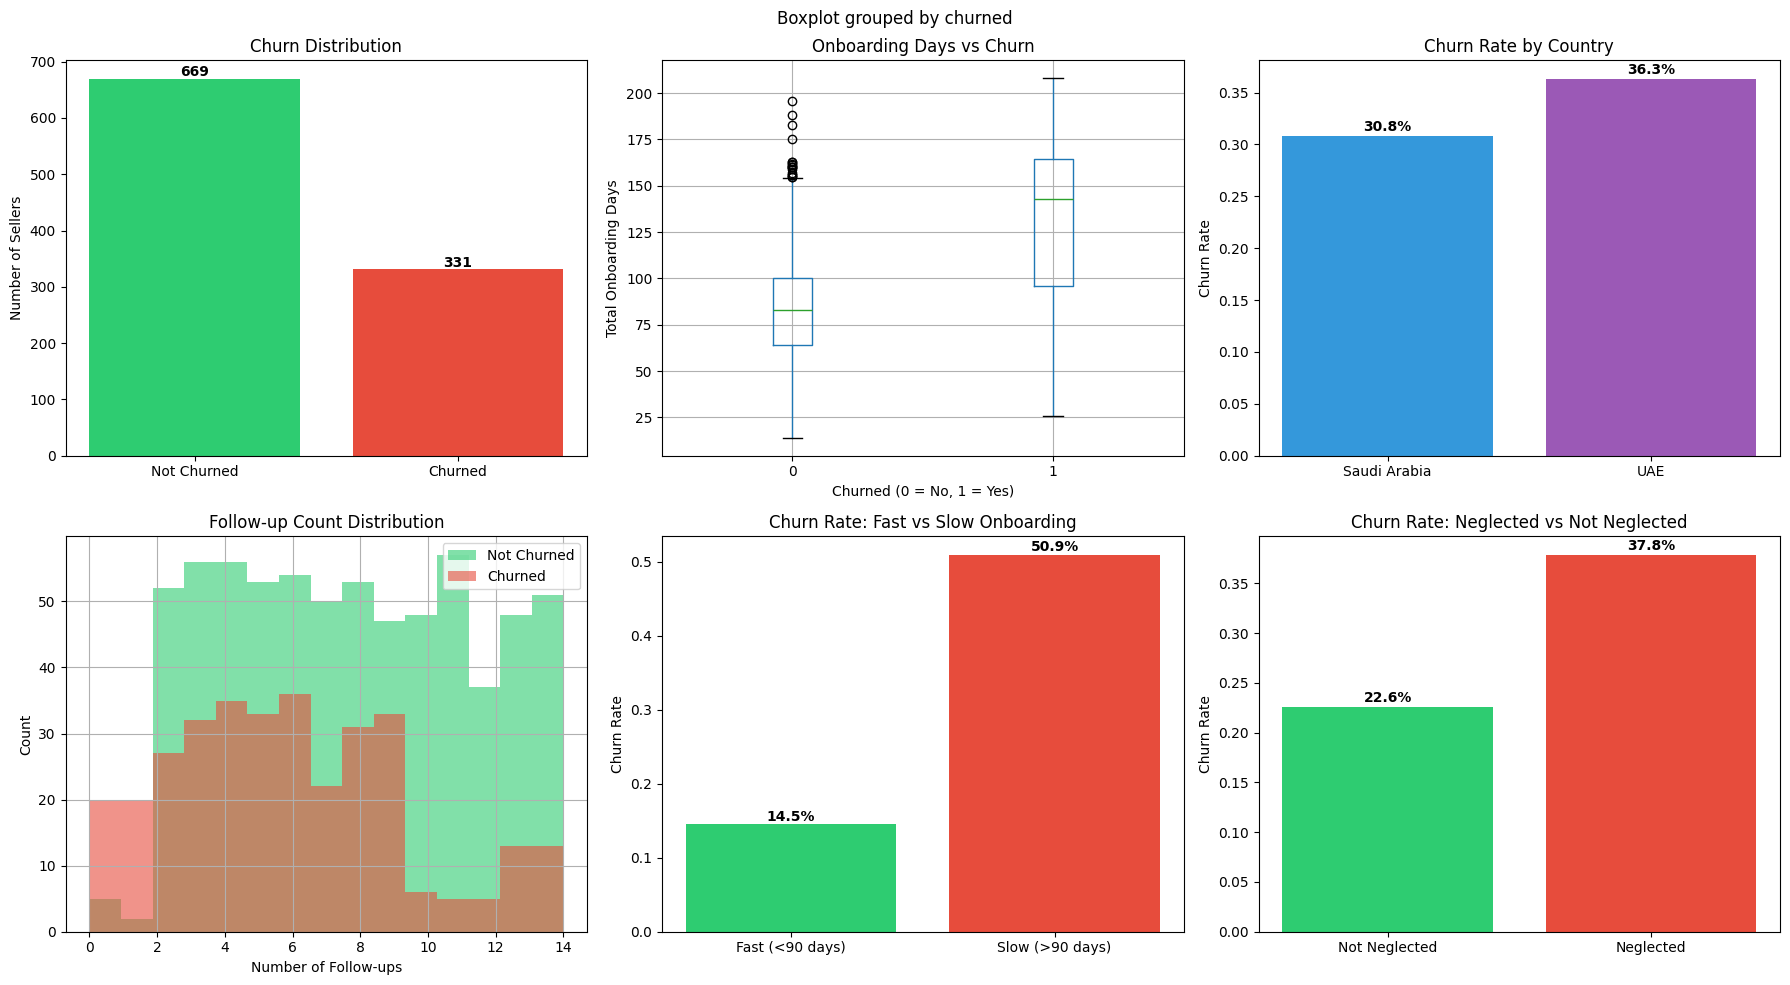

✅ EDA complete


In [112]:
# ── EDA: Numbers ──────────────────────────────────────────────

print("=" * 50)
print("📊 CHURN ANALYSIS — KEY NUMBERS")
print("=" * 50)

# Overall churn rate
print(f"\n🎯 Overall Churn Rate: {df['churned'].mean():.1%}")
print(f"   ├── Active Sellers:  {(df['churned'] == 0).sum()}")
print(f"   └── Churned Sellers: {(df['churned'] == 1).sum()}")

# Churn by country
print("\n🌍 Churn Rate by Country:")
country_stats = df.groupby("country")["churned"].agg(["mean", "sum", "count"])
country_stats.columns = ["Churn Rate", "Churned", "Total"]
country_stats["Churn Rate"] = country_stats["Churn Rate"].map("{:.1%}".format)
print(country_stats.to_string())

# Onboarding days by churn
print("\n⏱️  Average Onboarding Days:")
onboard_stats = df.groupby("churned")["total_onboarding_days"].agg(["mean", "median", "min", "max"])
onboard_stats.index = ["Not Churned", "Churned"]
print(onboard_stats.round(1).to_string())

# Follow-up stats by churn
print("\n📞 Average Follow-up Count:")
followup_stats = df.groupby("churned")["followup_count"].agg(["mean", "median"])
followup_stats.index = ["Not Churned", "Churned"]
print(followup_stats.round(1).to_string())

# Activation rate by churn
print("\n✅ Activation Rate:")
activation = df.groupby("churned")["reached_activation"].mean()
activation.index = ["Not Churned", "Churned"]
for label, val in activation.items():
    print(f"   {label}: {val:.1%}")

# Slow onboarding vs churn
print("\n🐢 Slow Onboarding (>90 days) Churn Rate:")
slow = df.groupby("is_slow_onboarding")["churned"].mean()
print(f"   Fast onboarding: {slow[0]:.1%} churn rate")
print(f"   Slow onboarding: {slow[1]:.1%} churn rate")

# Neglected sellers vs churn
print("\n📵 Neglected Sellers (no followup >30 days) Churn Rate:")
neglected = df.groupby("is_neglected")["churned"].mean()
print(f"   Not neglected: {neglected[0]:.1%} churn rate")
print(f"   Neglected:     {neglected[1]:.1%} churn rate")

print("\n" + "=" * 50)

# ── EDA: Visuals ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("🔍 Seller Churn Analysis — EDA", fontsize=16, fontweight="bold")

# Plot 1 — Churn distribution
churn_counts = df["churned"].value_counts()
axes[0, 0].bar(["Not Churned", "Churned"],
                churn_counts.values,
                color=["#2ecc71", "#e74c3c"])
for i, v in enumerate(churn_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha="center", fontweight="bold")
axes[0, 0].set_title("Churn Distribution")
axes[0, 0].set_ylabel("Number of Sellers")

# Plot 2 — Onboarding days by churn
df.boxplot(column="total_onboarding_days", by="churned", ax=axes[0, 1])
axes[0, 1].set_title("Onboarding Days vs Churn")
axes[0, 1].set_xlabel("Churned (0 = No, 1 = Yes)")
axes[0, 1].set_ylabel("Total Onboarding Days")

# Plot 3 — Churn rate by country
churn_by_country = df.groupby("country")["churned"].mean()
bars = axes[0, 2].bar(churn_by_country.index,
                       churn_by_country.values,
                       color=["#3498db", "#9b59b6"])
for bar, val in zip(bars, churn_by_country.values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2,
                     val + 0.005, f"{val:.1%}", ha="center", fontweight="bold")
axes[0, 2].set_title("Churn Rate by Country")
axes[0, 2].set_ylabel("Churn Rate")

# Plot 4 — Follow-up count distribution
df[df["churned"] == 0]["followup_count"].hist(
    ax=axes[1, 0], alpha=0.6, color="#2ecc71", label="Not Churned", bins=15)
df[df["churned"] == 1]["followup_count"].hist(
    ax=axes[1, 0], alpha=0.6, color="#e74c3c", label="Churned", bins=15)
axes[1, 0].set_title("Follow-up Count Distribution")
axes[1, 0].set_xlabel("Number of Follow-ups")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# Plot 5 — Slow onboarding vs churn rate
slow_churn = df.groupby("is_slow_onboarding")["churned"].mean()
axes[1, 1].bar(["Fast (<90 days)", "Slow (>90 days)"],
                slow_churn.values,
                color=["#2ecc71", "#e74c3c"])
for i, v in enumerate(slow_churn.values):
    axes[1, 1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")
axes[1, 1].set_title("Churn Rate: Fast vs Slow Onboarding")
axes[1, 1].set_ylabel("Churn Rate")

# Plot 6 — Neglected sellers vs churn rate
neglect_churn = df.groupby("is_neglected")["churned"].mean()
axes[1, 2].bar(["Not Neglected", "Neglected"],
                neglect_churn.values,
                color=["#2ecc71", "#e74c3c"])
for i, v in enumerate(neglect_churn.values):
    axes[1, 2].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")
axes[1, 2].set_title("Churn Rate: Neglected vs Not Neglected")
axes[1, 2].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()
print("✅ EDA complete")

In [113]:
# Encode country column (Saudi Arabia = 0, UAE = 1)
le = LabelEncoder()
df["country_encoded"] = le.fit_transform(df["country"])

# Define features and target
features = [
    "days_to_complete_company_details",
    "days_to_complete_logistics",
    "days_to_upload_license",
    "days_to_sign_agreement",
    "total_onboarding_days",
    "followup_count",
    "days_since_last_followup",
    "reached_activation",
    "days_since_application",
    "avg_days_per_step",
    "followup_effectiveness",
    "is_slow_onboarding",
    "is_neglected",
    "country_encoded"
]

X = df[features]
y = df["churned"]

# Split into train and test — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Preprocessing complete")
print(f"🏋️  Training set: {X_train.shape[0]} sellers")
print(f"🧪 Test set:     {X_test.shape[0]} sellers")

✅ Preprocessing complete
🏋️  Training set: 800 sellers
🧪 Test set:     200 sellers


In [114]:
# ── Model 1: Logistic Regression ─────────────────────────────
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# ── Model 2: Random Forest ────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

print("✅ Models trained successfully")
print(f"   ├── Logistic Regression: done")
print(f"   └── Random Forest:       done")

✅ Models trained successfully
   ├── Logistic Regression: done
   └── Random Forest:       done



📊 Logistic Regression

📋 Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.77      0.84      0.81       122
     Churned       0.72      0.62      0.66        78

    accuracy                           0.76       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.75      0.76      0.75       200

🎯 F1 Score:  0.662
📈 ROC-AUC:   0.730

📊 Random Forest

📋 Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.77      0.93      0.84       122
     Churned       0.85      0.56      0.68        78

    accuracy                           0.79       200
   macro avg       0.81      0.75      0.76       200
weighted avg       0.80      0.79      0.78       200

🎯 F1 Score:  0.677
📈 ROC-AUC:   0.749


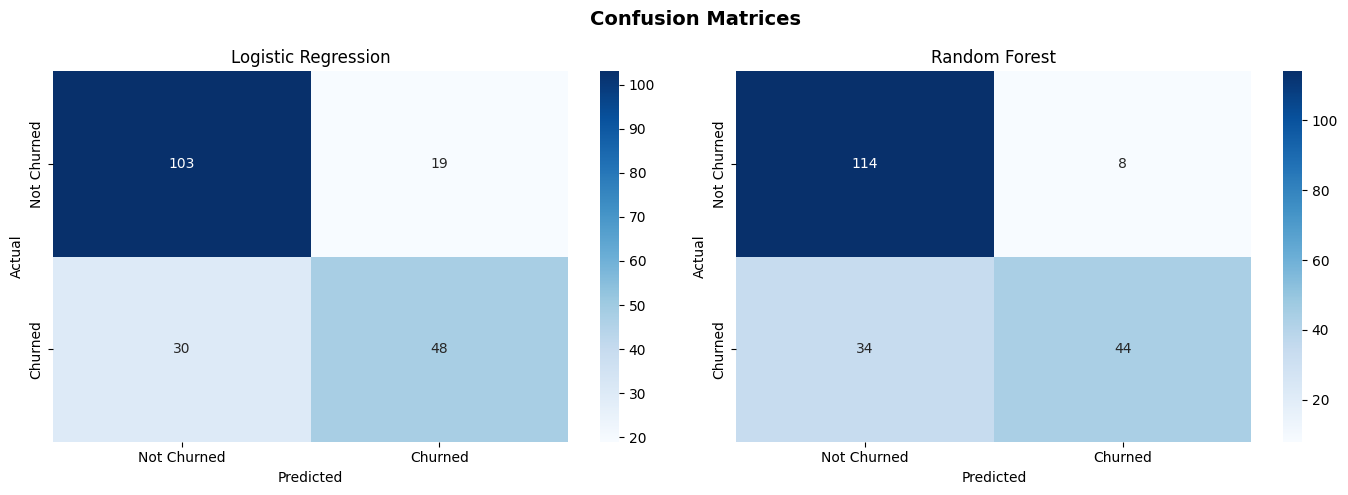

In [115]:
# ── Evaluation Function ───────────────────────────────────────
def evaluate_model(name, y_test, predictions):
    print(f"\n{'='*50}")
    print(f"📊 {name}")
    print(f"{'='*50}")
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, predictions,
                                 target_names=["Not Churned", "Churned"]))
    print(f"🎯 F1 Score:  {f1_score(y_test, predictions):.3f}")
    print(f"📈 ROC-AUC:   {roc_auc_score(y_test, predictions):.3f}")

# ── Evaluate Both Models ──────────────────────────────────────
evaluate_model("Logistic Regression", y_test, lr_predictions)
evaluate_model("Random Forest",       y_test, rf_predictions)

# ── Confusion Matrix Visuals ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

for ax, predictions, title in zip(
    axes,
    [lr_predictions, rf_predictions],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Churned", "Churned"],
                yticklabels=["Not Churned", "Churned"])
    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

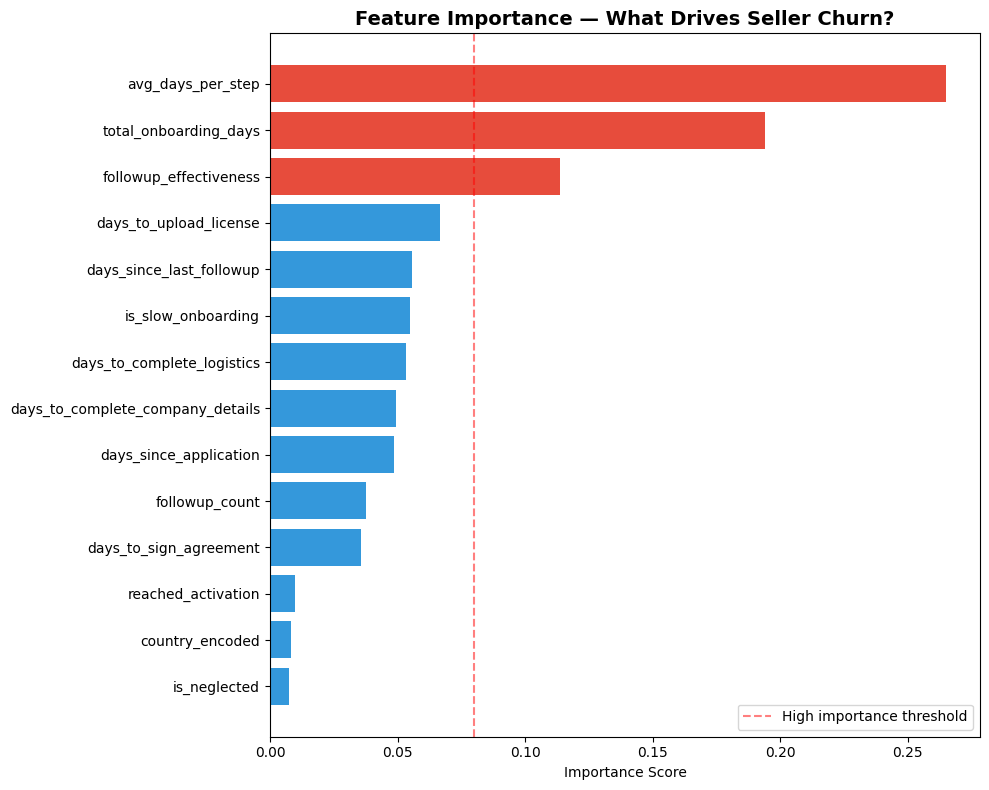


🏆 Top 5 Most Important Features:
   avg_days_per_step                        0.265
   total_onboarding_days                    0.194
   followup_effectiveness                   0.114
   days_to_upload_license                   0.067
   days_since_last_followup                 0.056


In [116]:
# ── Feature Importance — Random Forest ───────────────────────
feature_importance = pd.DataFrame({
    "feature":   features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ["#e74c3c" if imp > 0.08 else "#3498db"
          for imp in feature_importance["importance"]]
plt.barh(feature_importance["feature"],
         feature_importance["importance"],
         color=colors)
# Title
plt.title("Feature Importance — What Drives Seller Churn?",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.axvline(x=0.08, color="red", linestyle="--", alpha=0.5, label="High importance threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Print top 5 features
print("\n🏆 Top 5 Most Important Features:")
top5 = feature_importance.sort_values("importance", ascending=False).head(5)
for i, row in top5.iterrows():
    print(f"   {row['feature']:40s} {row['importance']:.3f}")

In [117]:
import joblib

# Save the Random Forest model
joblib.dump(rf_model, "churn_model.pkl")
joblib.dump(scaler,   "scaler.pkl")

# Save the dataset
df.to_csv("synthetic_sellers.csv", index=False)

print("✅ Model saved:   churn_model.pkl")
print("✅ Scaler saved:  scaler.pkl")
print("✅ Dataset saved: synthetic_sellers.csv")

✅ Model saved:   churn_model.pkl
✅ Scaler saved:  scaler.pkl
✅ Dataset saved: synthetic_sellers.csv
